In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_excel('Math_9th.xlsx')

In [3]:
df.head()

,Years,Exercise_id,Exercise,Appeared,Chapter
0,2025,1,1.1,1,Matrices
1,2025,2,1.2,0,Matrices
2,2025,3,1.3,1,Matrices
3,2025,4,1.4,0,Matrices
4,2025,5,1.5,0,Matrices


In [4]:
df.isnull().sum()

Years          0
Exercise_id    0
Exercise       0
Appeared       0
Chapter        0
dtype: int64

In [5]:
df['Appeared'].value_counts()

Appeared
0    464
1    192
Name: count, dtype: int64

In [6]:
df = df.sort_values(['Exercise', 'Years']).reset_index(drop=True)

In [7]:
gaps=[]
last_year_since_appeared={}
for _, row in df.iterrows():
    exercise=row['Exercise']
    year=int(row['Years'])
    appeared=row['Appeared']
    if exercise not in last_year_since_appeared:
        gaps.append(-1)
    else:
        gaps.append(year - last_year_since_appeared[exercise])
    if appeared==1:
        last_year_since_appeared[exercise]=year
df['Gaps']=gaps

In [8]:
years_in_data = df['Years'].unique()

frequency = []

for _, row in df.iterrows():
    exercise = row['Exercise']
    year = row['Years']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Exercise'] == exercise]
    count = topic_data[topic_data['Years'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [9]:

df['Appeared_last_year'] = df.groupby('Exercise')['Appeared'].shift(1).fillna(0)

# rolling_3
df['rolling_3'] = (df.groupby('Exercise')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [10]:
df['Chapter'].unique()

array(['Sides and Angles of Triangles', 'Matrices',
       'Real and Complex Numbers', 'Logarithm',
       'Algebraic Expression and Algebraib Formulas', 'Factorization',
       'Algebraic Manipulation', 'Linear Equations and Inequalities',
       'Linear Graphs and their Application',
       'Introduction to Coordinate Geometry', 'Congruent Triangles',
       'Parallelograms and Triangles',
       'Line Bisectors and Angle Bisectors', 'Ratio and Proportion',
       'Pythagoras Theorem', 'Theorems Related with Area',
       'Parctical Geometry Triangles'], dtype=object)

In [11]:
weight_dict={
    'Sides and Angles of Triangles':0.06
    , 'Matrices':0.07,
       'Real and Complex Numbers':0.11
       , 'Logarithm':0.05,
       'Algebraic Expression and Algebraib Formulas':0.09
       , 'Factorization':0.04,
       'Algebraic Manipulation':0.04
       , 'Linear Equations and Inequalities':0.08,
       'Linear Graphs and their Application':0.04,
       'Introduction to Coordinate Geometry':0.04
       , 'Congruent Triangles':0.04,
       'Parallelograms and Triangles':0.04,
       'Line Bisectors and Angle Bisectors':0.06
       , 'Ratio and Proportion':0.06,
       'Pythagoras Theorem':0.06
       , 'Theorems Related with Area':0.06,
       'Parctical Geometry Triangles':0.06

}

In [12]:
df['chapter_weight']=df['Chapter'].map(weight_dict)

In [13]:
df['Exercise'] = df['Exercise'].astype(str)

In [14]:
df.to_excel('Dataset_9th_Class_Maths_Updated.xlsx', index=False)

In [15]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [16]:
train = df_model[df_model['Years'] < 2025]
test  = df_model[df_model['Years'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [17]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced',random_state=42)
lr_model.fit(X_train,y_train)
lr_predict=lr_model.predict(X_test)

### Accuracy , Precision , Recall

In [18]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
accuracy_lr=accuracy_score(y_test,lr_predict)
precision_lr=precision_score(y_test,lr_predict)
recall_lr=recall_score(y_test,lr_predict)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  85.37%
Precision:69.70%
Recall:92.00%


In [19]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.6951


### Accuarcy , Classification Report On Different Threshold

In [20]:
from sklearn.metrics import classification_report

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:85.37%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        57
           1       0.70      0.92      0.79        25

    accuracy                           0.85        82
   macro avg       0.83      0.87      0.84        82
weighted avg       0.88      0.85      0.86        82

Accuracy:71.95%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        57
           1       0.52      1.00      0.68        25

    accuracy                           0.72        82
   macro avg       0.76      0.80      0.72        82
weighted avg       0.85      0.72      0.73        82

Accuracy:36.59%

Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      0.09      0.16        57
           1       0.32      1.00      0.49        25

    accuracy                           0.37        82
   macro avg       0.66      0.54  

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Years'] == 2025][['Exercise_id', 'Exercise', 'Chapter', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Years'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Exercise_id', 'Exercise', 'Chapter', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    exercise = row['Exercise']
    years = df[
        (df['Exercise'] == exercise) &
        (df['Appeared'] == 1)
    ]['Years'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Math_9th_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Exercise_id Exercise                                      Chapter  \
0            11      2.5                     Real and Complex Numbers   
1             8      2.2                     Real and Complex Numbers   
2            36      7.3            Linear Equations and Inequalities   
3             6      1.6                                     Matrices   
4             9      2.3                     Real and Complex Numbers   
5             7      2.1                     Real and Complex Numbers   
6            80     17.1                 Parctical Geometry Triangles   
7            24      4.7  Algebraic Expression and Algebraib Formulas   
8            17      3.6                                    Logarithm   
9            20      4.3  Algebraic Expression and Algebraib Formulas   
10           31      6.1                       Algebraic Manipulation   
11           45  Th 10.2                          Congruent Triangles   
12           42      9.2          Introduction to C

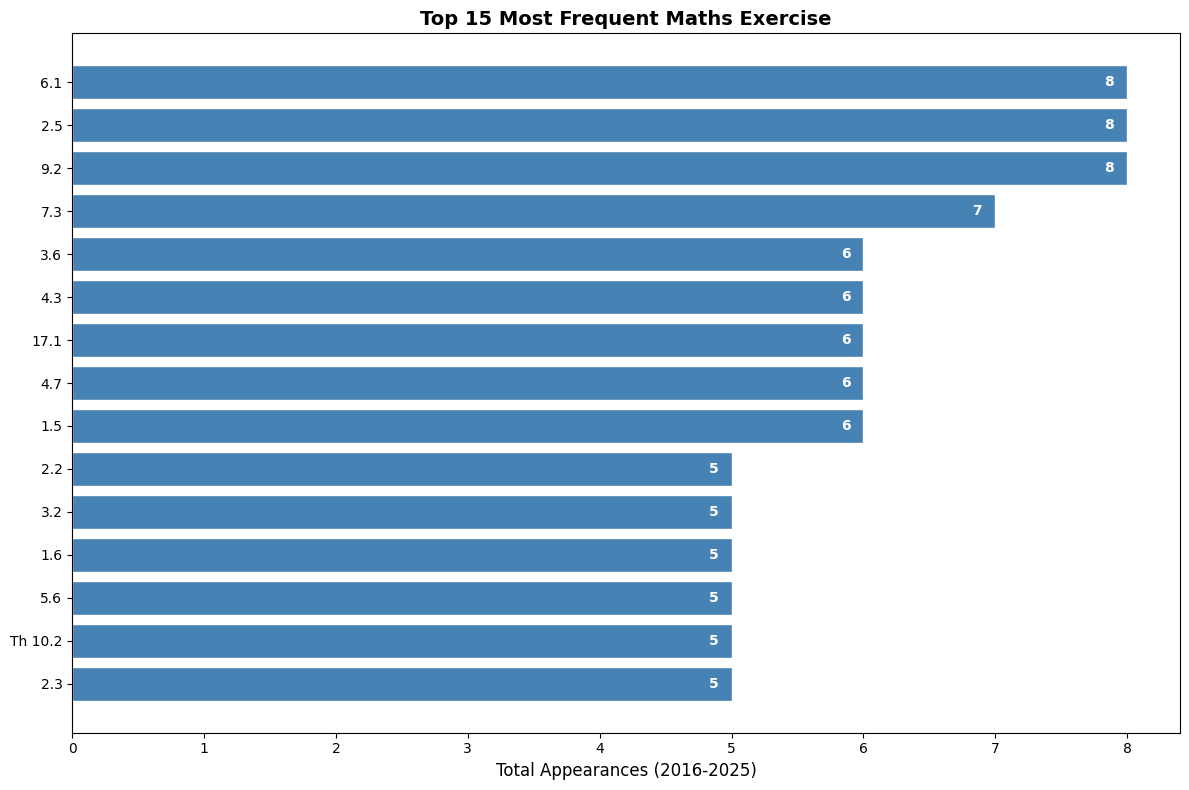

In [24]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Exercise')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Maths Exercise', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

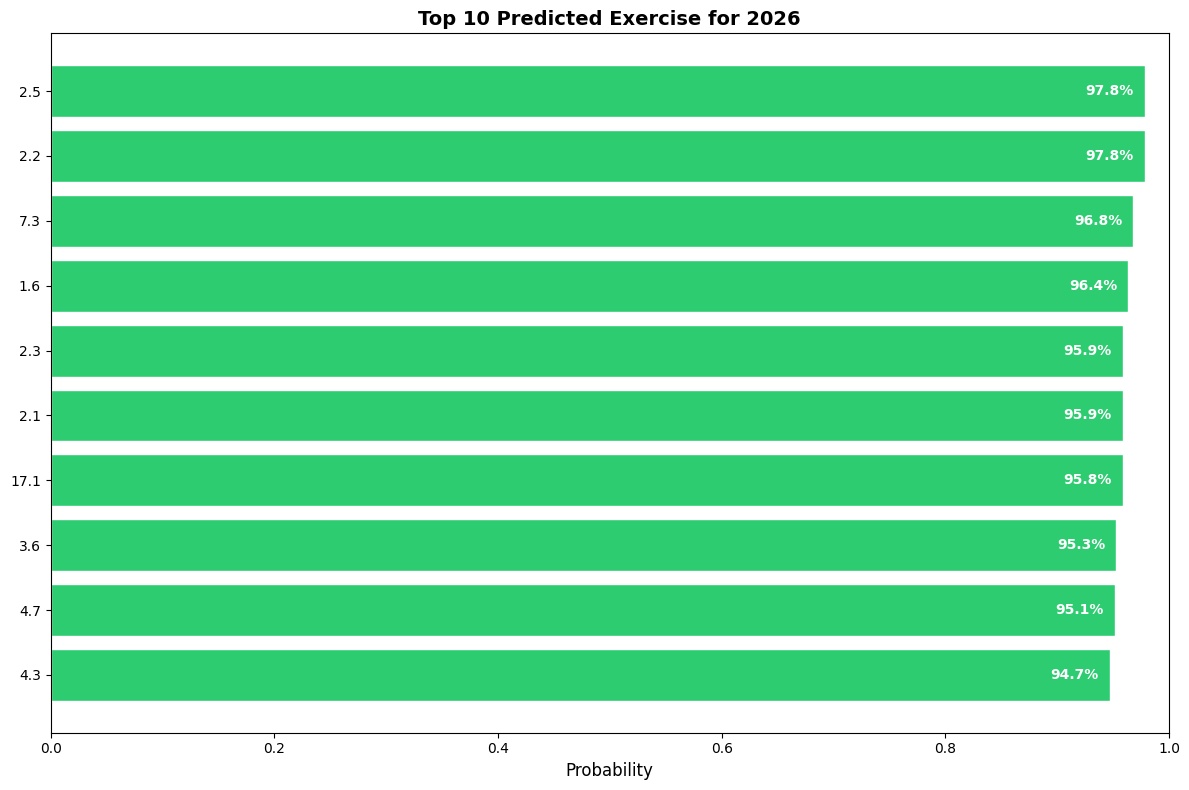

In [25]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Exercise'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Exercise for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()

"Math mein exercise-level granularity hai, topic-level nahi. Board consistently specific exercises se questions leta hai — isliye historical signal strong hai aur model high confidence de raha hai."